In [1]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

#### Constants

In [2]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

str_dirname_output = './output'

flt_factor_24_to_72 = 2.36

# id cols
list_cols_id = [
    'request_datetime',
    'accountid',
    'bitdebtor',
]

# ivs
list_cols_structure = [
    'ENG-wtd_avg',
    'ENG-bk',
    'bookvalue__app',
    'amtfinanced__app',
    'ENG-loan_to_value',
    'fltgrossmonthly__income_sum',
    'ENG-franchise',
    'rp01s__tu',
    'g232s__tu',
    'g106s__tu',
    'ENG-has_codebtor',
    'ENG-has_auto',
    'derogseverityindex__ln',
    'balmag01__tu',
    'cv15__tu',
]

# col w institutions
list_cols_inst = [
    'str_institution__tu_pmthx',
]

# targets
list_str_target = [
    'Early_Pay_Delinquency_15_60_Flag',
    'Early_Pay_Delinquency_30_90_Flag',
    'Early_Pay_Delinquency_30_180_Flag',
    'Early_Pay_Delinquency_30_360_Flag',
    'Early_Pay_Delinquency_60_720_Flag',
#     'loss_at_60',
#     'loss_at_180',
#     'loss_at_360',
    'loss_at_720',
]

# list cols
list_cols = list_cols_id + list_cols_structure + list_cols_inst + list_str_target
int_len = len(list_cols)
print(f'Importing {int_len} columns')

list_str_inst = [
    # from ben: 2025-02-21
    'CURRENT',
    'SELF',
    # key words
    'CHIME-STRIDE',
    'CHIMEFINAL',
    # from dustin: 2025-02-24
    'SELF FIN',
    'SELF/LEAD',
    'SELFINC/LEAD',
    'SBNASELFLNDR',
    'SBNA SELF',
    'CHIME',
    'CLEO',
    'CLEO AI',
    'VARO',
    'ATLAS',
    'ATLCAPBKSELF',
    'POSSIBLE',
    'POSSIBLE FIN',
    'KIKOFF',
    'SUPER.COM',
    'STEP',
    'STEP MOBILE',
    'BRIGHT',
    'BRIGHT BLDR',
    'FIG TECH INC',
    'SELF/RENT',
    'SELFBILLSE',
    'PROGRESSRES',
    'FLEX',
    'FLEXFINANCE',
]

Project: 20250221-credit-builder-analysis
Task: 03_analysis
Importing 25 columns


#### Output dir

In [3]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Import data

In [4]:
str_filename = 'df.gzip'
str_uri = f's3://20241112-simple-model-test/08_prep_data/{str_filename}'
df = pd.read_parquet(
    str_uri,
    columns=list_cols,
)
# sort
df.sort_values(by='request_datetime', ascending=True, inplace=True)
df

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/fsspec/registry.py:283: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


,request_datetime,accountid,bitdebtor,ENG-wtd_avg,ENG-bk,bookvalue__app,amtfinanced__app,ENG-loan_to_value,fltgrossmonthly__income_sum,ENG-franchise,...,derogseverityindex__ln,balmag01__tu,cv15__tu,str_institution__tu_pmthx,Early_Pay_Delinquency_15_60_Flag,Early_Pay_Delinquency_30_90_Flag,Early_Pay_Delinquency_30_180_Flag,Early_Pay_Delinquency_30_360_Flag,Early_Pay_Delinquency_60_720_Flag,loss_at_720
0,2021-07-26 16:29:29.3903686,5702434,1,0.616667,1,10900.0,14292.30,1.311220,2426.67,1,...,3.0,144.0,5.0,"['CAPITAL ONE', 'FST PREMIER', 'VERIDIAN CU', ...",0,0,0,0,0,0.00
1,2021-07-26 16:39:34.1121025,5714239,1,NaN,0,17294.0,24771.37,1.432368,5809.68,1,...,3.0,218.0,1.0,"['MTN AMER CU', 'MTN AMER CU', 'MID CITY FIN']",1,0,1,1,1,7827.16
2,2021-07-26 16:48:39.3211104,5713063,1,NaN,1,10830.0,17188.00,1.587073,3758.84,1,...,1.0,NaN,3.0,"['NAVIENT', 'NLS', 'FST PREMIER', 'SHELLPOINT'...",0,0,0,0,0,0.00
3,2021-07-27 09:02:35.3300974,5713732,1,1.000000,0,24150.0,26127.42,1.081881,5416.67,0,...,1.0,397.0,5.0,"['CAPITAL ONE', 'CB INDIGO', 'CHIME-STRIDE', '...",0,0,1,1,1,0.00
4,2021-07-27 09:18:12.2190097,5715634,1,1.000000,0,13530.0,18554.36,1.371350,4786.97,1,...,0.0,NaN,1.0,"['ARIZ FED CU', 'ARIZ FED CU']",0,0,0,0,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94472,2024-11-26 06:16:16+00:00,8420588,1,0.030636,0,23850.0,30550.82,1.280957,8085.73,0,...,4.0,436.0,3.0,"['FST PREMIER', 'CONNS', 'STATECU', 'OPENSKY C...",1,0,0,0,0,0.00
94473,2024-11-26 06:21:44+00:00,8401043,1,0.367073,1,23087.0,27678.30,1.198869,5860.43,1,...,1.0,362.0,1.0,"['CAPITAL ONE', 'CAPITAL ONE', 'NAVY FCU', 'DO...",1,1,1,1,0,0.00
94474,2024-11-26 06:25:09+00:00,8414683,1,NaN,0,14272.0,18742.43,1.313231,5148.74,1,...,1.0,300.0,3.0,"['LENDMARK', 'LENDMARK', 'CB INDIGO', 'LENDMAR...",1,0,0,0,0,0.00
94475,2024-11-26 06:32:28+00:00,8359085,1,0.006585,1,23788.0,23587.85,0.991586,5062.70,1,...,1.0,240.0,2.0,"['MAF AUTO', 'EDFINANCIAL', 'EDFINANCIAL', 'ED...",0,0,0,0,0,0.00


#### Get Gen 12 predictions

In [5]:
list_cols = [
    'accountid',
    'bitdebtor',
    'request_datetime',
    'ad',
    'pd',
    'lgd',
]

str_filename = 'df_clean_w_pred.gzip'
str_uri = f's3://{str_project}/01_gen12_predictions/{str_filename}'
df_tmp = pd.read_parquet(
    str_uri,
    columns=list_cols,
)
df_tmp['ecnl'] = df_tmp['pd'] * df_tmp['lgd'] * flt_factor_24_to_72
# rename
dict_rename =  {
    'ad': 'gen12_ad',
    'pd': 'gen12_pd',
    'lgd': 'gen12_lgd',
    'ecnl': 'gen12_ecnl',
}
df_tmp.rename(columns=dict_rename, inplace=True)
# join
df = pd.merge(
    left=df,
    right=df_tmp,
    on=['accountid','bitdebtor','request_datetime'],
    how='left',
)
# show
#df

#### Get Gen 13 predictions

In [6]:
list_cols = [
    'accountid',
    'bitdebtor',
    'request_datetime',
    'pd',
    'lgd',
]

str_filename = 'df_clean_w_pred.gzip'
str_uri = f's3://{str_project}/02_gen13_predictions/{str_filename}'
df_tmp = pd.read_parquet(
    str_uri,
    columns=list_cols,
)
df_tmp['ecnl'] = df_tmp['pd'] * df_tmp['lgd'] * flt_factor_24_to_72
# rename
dict_rename =  {
    'pd': 'gen13_pd',
    'lgd': 'gen13_lgd',
    'ecnl': 'gen13_ecnl',
}
df_tmp.rename(columns=dict_rename, inplace=True)
# join
df = pd.merge(
    left=df,
    right=df_tmp,
    on=['accountid','bitdebtor','request_datetime'],
    how='left',
)
# show
df

,request_datetime,accountid,bitdebtor,ENG-wtd_avg,ENG-bk,bookvalue__app,amtfinanced__app,ENG-loan_to_value,fltgrossmonthly__income_sum,ENG-franchise,...,Early_Pay_Delinquency_30_360_Flag,Early_Pay_Delinquency_60_720_Flag,loss_at_720,gen12_ad,gen12_pd,gen12_lgd,gen12_ecnl,gen13_pd,gen13_lgd,gen13_ecnl
0,2021-07-26 16:29:29.3903686,5702434,1,0.616667,1,10900.0,14292.30,1.311220,2426.67,1,...,0,0,0.00,0.268054,0.052721,0.682529,0.084922,0.578671,0.323245,0.441444
1,2021-07-26 16:39:34.1121025,5714239,1,NaN,0,17294.0,24771.37,1.432368,5809.68,1,...,1,1,7827.16,0.421207,0.242853,0.636985,0.365077,0.353818,0.390043,0.325690
2,2021-07-26 16:48:39.3211104,5713063,1,NaN,1,10830.0,17188.00,1.587073,3758.84,1,...,0,0,0.00,0.249006,0.234714,0.745692,0.413058,0.439522,0.416230,0.431744
3,2021-07-27 09:02:35.3300974,5713732,1,1.000000,0,24150.0,26127.42,1.081881,5416.67,0,...,1,1,0.00,0.514731,0.309557,0.691098,0.504885,0.449619,0.337281,0.357889
4,2021-07-27 09:18:12.2190097,5715634,1,1.000000,0,13530.0,18554.36,1.371350,4786.97,1,...,0,0,0.00,0.244784,0.165092,0.618661,0.241041,0.350417,0.390043,0.322559
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94472,2024-11-26 06:16:16+00:00,8420588,1,0.030636,0,23850.0,30550.82,1.280957,8085.73,0,...,0,0,0.00,0.610044,0.207462,0.620092,0.303603,0.712814,0.390043,0.656146
94473,2024-11-26 06:21:44+00:00,8401043,1,0.367073,1,23087.0,27678.30,1.198869,5860.43,1,...,1,0,0.00,0.255144,0.112541,0.606080,0.160973,0.381784,0.289997,0.261290
94474,2024-11-26 06:25:09+00:00,8414683,1,NaN,0,14272.0,18742.43,1.313231,5148.74,1,...,0,0,0.00,0.605399,0.087163,0.650510,0.133813,0.627651,0.390043,0.577753
94475,2024-11-26 06:32:28+00:00,8359085,1,0.006585,1,23788.0,23587.85,0.991586,5062.70,1,...,0,0,0.00,0.292850,0.161923,0.701278,0.267984,0.356685,0.172898,0.145542


#### Get the dlv1 accounts

In [7]:
str_filename = 'df_direct.csv'
str_uri = f's3://20250121-gen-13-model-monitoring/05_remove_direct/{str_filename}'
df_tmp = pd.read_csv(str_uri)
df_tmp['ACCOUNTID'] = df_tmp['ACCOUNTID'].astype(int)
list_int_account = list(df_tmp['ACCOUNTID'])
list_int_account = list(dict.fromkeys(list_int_account))
int_naccounts = len(list_int_account)
print(f'Number of direct accounts: {int_naccounts}')

Number of direct accounts: 70117


#### Remove

In [8]:
df['accountid'] = df['accountid'].astype(int)
df['tag'] = df['accountid'].apply(
    lambda x: 1 if x in list_int_account else 0,
)
df = df[df['tag'] == 0].copy()
df.drop('tag', axis=1, inplace=True)
# show
df

,request_datetime,accountid,bitdebtor,ENG-wtd_avg,ENG-bk,bookvalue__app,amtfinanced__app,ENG-loan_to_value,fltgrossmonthly__income_sum,ENG-franchise,...,Early_Pay_Delinquency_30_360_Flag,Early_Pay_Delinquency_60_720_Flag,loss_at_720,gen12_ad,gen12_pd,gen12_lgd,gen12_ecnl,gen13_pd,gen13_lgd,gen13_ecnl
0,2021-07-26 16:29:29.3903686,5702434,1,0.616667,1,10900.0,14292.30,1.311220,2426.67,1,...,0,0,0.00,0.268054,0.052721,0.682529,0.084922,0.578671,0.323245,0.441444
1,2021-07-26 16:39:34.1121025,5714239,1,NaN,0,17294.0,24771.37,1.432368,5809.68,1,...,1,1,7827.16,0.421207,0.242853,0.636985,0.365077,0.353818,0.390043,0.325690
2,2021-07-26 16:48:39.3211104,5713063,1,NaN,1,10830.0,17188.00,1.587073,3758.84,1,...,0,0,0.00,0.249006,0.234714,0.745692,0.413058,0.439522,0.416230,0.431744
3,2021-07-27 09:02:35.3300974,5713732,1,1.000000,0,24150.0,26127.42,1.081881,5416.67,0,...,1,1,0.00,0.514731,0.309557,0.691098,0.504885,0.449619,0.337281,0.357889
4,2021-07-27 09:18:12.2190097,5715634,1,1.000000,0,13530.0,18554.36,1.371350,4786.97,1,...,0,0,0.00,0.244784,0.165092,0.618661,0.241041,0.350417,0.390043,0.322559
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94472,2024-11-26 06:16:16+00:00,8420588,1,0.030636,0,23850.0,30550.82,1.280957,8085.73,0,...,0,0,0.00,0.610044,0.207462,0.620092,0.303603,0.712814,0.390043,0.656146
94473,2024-11-26 06:21:44+00:00,8401043,1,0.367073,1,23087.0,27678.30,1.198869,5860.43,1,...,1,0,0.00,0.255144,0.112541,0.606080,0.160973,0.381784,0.289997,0.261290
94474,2024-11-26 06:25:09+00:00,8414683,1,NaN,0,14272.0,18742.43,1.313231,5148.74,1,...,0,0,0.00,0.605399,0.087163,0.650510,0.133813,0.627651,0.390043,0.577753
94475,2024-11-26 06:32:28+00:00,8359085,1,0.006585,1,23788.0,23587.85,0.991586,5062.70,1,...,0,0,0.00,0.292850,0.161923,0.701278,0.267984,0.356685,0.172898,0.145542


#### Make a tag at the account level if pmt hx is bad

In [9]:
df_tmp = df.groupby('accountid', as_index=False).agg({
    'ENG-wtd_avg': 'mean',
})
df_tmp['tag'] = df_tmp['ENG-wtd_avg'].apply(
    lambda x: 1 if x < 0.5 else 0,
)
flt_mn = df_tmp['tag'].mean()
print(f'Proportion of accounts with bad pmt hx: {flt_mn:0.4f}')
df_tmp = df_tmp[df_tmp['tag'] == 1].copy()
df_tmp['accountid'] = df_tmp['accountid'].astype(int)
list_accountid = list(df_tmp['accountid'])
# creat tag
df['bad_pmt_hx'] = df['accountid'].apply(
    lambda x: 1 if x in list_accountid else 0,
)
# show
#df

Proportion of accounts with bad pmt hx: 0.2367


#### Get chargeoff severity

In [10]:
df['co_at_720'] = df['loss_at_720'] / df['amtfinanced__app']
# make min 0
df['co_at_720'] = df['co_at_720'].clip(lower=0)
# show
#df

#### Make 60+ in 720 and positive net charge off

In [11]:
df['60_plus_pos_co_at_720'] = df.apply(
    lambda x: 1 if (x['Early_Pay_Delinquency_60_720_Flag'] == 1) and (x['co_at_720'] > 0) else 0,
    axis=1,
)
# show
#df

#### Create a new column that is a list

In [12]:
df['list_institutions'] = df['str_institution__tu_pmthx'].apply(
    lambda x: eval(x.replace('nan','None')),
)
df['list_institutions'] = df['list_institutions'].apply(
    lambda x: [] if x is None else x,
)
# show
#df

#### Get the unique names for institutions

In [13]:
list_str_inst_flat = list(df['list_institutions'].explode().dropna())
list_str_inst_flat = list(dict.fromkeys(list_str_inst_flat))
int_len = len(list_str_inst_flat)
print(f'There are {int_len} unique institutions')

There are 9526 unique institutions


#### Find any with keywords

In [14]:
list_cols = [col for col in list_str_inst_flat if 'chime' in col.lower()]
list_cols

['CHIME-STRIDE', 'CHIMEFINAL']

#### Create tag for institutions

In [15]:
list_str_col_new = []
for str_inst in tqdm(list_str_inst):
    str_col_new = f'{str_inst}_tag'
    df[str_col_new] = df['list_institutions'].apply(
        lambda x: 1 if str_inst in x else 0,
    )
    list_str_col_new.append(str_col_new)

# show
#df

100%|██████████| 29/29 [00:01<00:00, 18.69it/s]


#### Tag if there was an institution of interest

In [16]:
df['sum'] = df[list_str_col_new].sum(axis=1)
df['has_inst_tag'] = df['sum'].apply(
    lambda x: 1 if x > 0 else 0,
)
flt_mn = df['has_inst_tag'].mean()
print(f'Proportion has tag: {flt_mn:0.4f}')
# show
#df

Proportion has tag: 0.2053


#### Save to s3

In [17]:
%%time

str_filename = 'df_institutions.gzip'
str_uri = f's3://{str_project}/{str_task}/{str_filename}'
df.to_parquet(
    str_uri,
    compression='gzip',
)

CPU times: user 2.02 s, sys: 64.1 ms, total: 2.09 s
Wall time: 2.56 s


#### ECNL by chime (no targets yet because we are using newer data)

In [18]:
df_tmp = df.groupby(by='accountid', as_index=False).agg({
    'has_inst_tag': 'max',
    'gen12_ad': 'mean',
    'gen12_pd': 'mean',
    'gen12_lgd': 'mean',
    'gen13_pd': 'mean',
    'gen13_lgd': 'mean',
})
# gen ecnls
df_tmp['gen12_ecnl'] = df_tmp['gen12_pd'] * df_tmp['gen12_lgd'] * flt_factor_24_to_72
df_tmp['gen13_ecnl'] = df_tmp['gen13_pd'] * df_tmp['gen13_lgd'] * flt_factor_24_to_72
# group by has_inst_tag
df_tmp = df_tmp.groupby(by='has_inst_tag', as_index=False).agg({
    'gen12_ad': 'mean',
    'gen12_pd': 'mean',
    'gen12_lgd': 'mean',
    'gen12_ecnl': 'mean',
    'gen13_pd': 'mean',
    'gen13_lgd': 'mean',
    'gen13_ecnl': 'mean',
})

# map
dict_map = {
    1: 'Yes',
    0: 'No',
}
df_tmp['has_inst_tag'] = df_tmp['has_inst_tag'].map(dict_map)

# save
str_filename = 'df_pivot_all_scores.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_tmp.to_csv(str_local_path, index=False)

# show
df_tmp

,has_inst_tag,gen12_ad,gen12_pd,gen12_lgd,gen12_ecnl,gen13_pd,gen13_lgd,gen13_ecnl
0,No,0.428544,0.243532,0.654660,0.378577,0.441120,0.35274,0.372129
1,Yes,0.459938,0.259518,0.660237,0.406928,0.495805,0.35400,0.417209


#### Rate over time

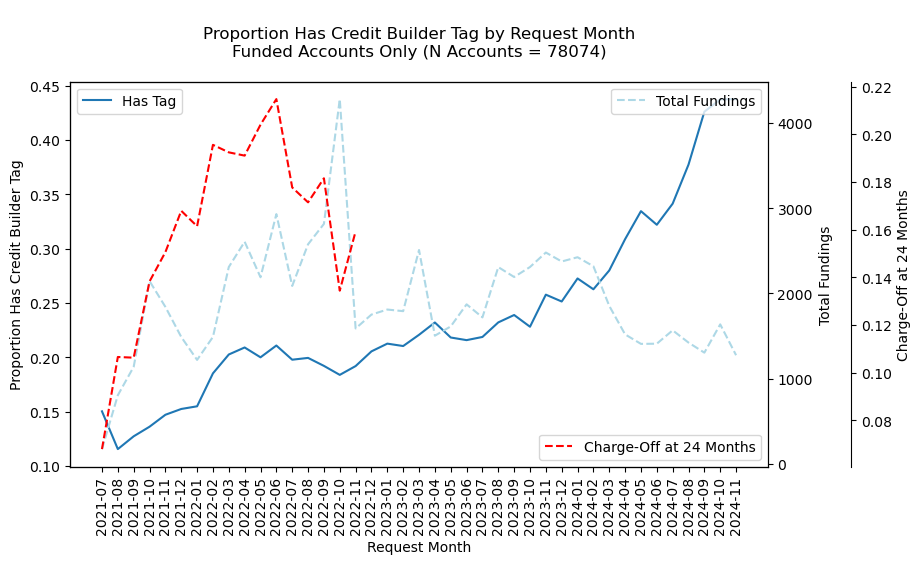

In [19]:
df_tmp = df.groupby(by='accountid', as_index=False).agg({
    'request_datetime': 'first',
    'has_inst_tag': 'max',
    'co_at_720': 'first',
})
int_nrows = df_tmp.shape[0]
df_tmp['request_month'] = df_tmp['request_datetime'].apply(
    lambda x: str(x)[:7],
)
df_tmp['count'] = 1
df_tmp = df_tmp.groupby('request_month', as_index=False).agg({
    'count': 'sum',
    'has_inst_tag': 'mean',
    'co_at_720': 'mean',
})

# graph
x = df_tmp['request_month']
y = df_tmp['has_inst_tag']
z = df_tmp['count']
a = df_tmp['co_at_720']

# ax
fig, ax = plt.subplots(figsize=(9,5))
str_title = f"""
Proportion Has Credit Builder Tag by Request Month
Funded Accounts Only (N Accounts = {int_nrows})
"""
ax.set_title(str_title)
ax.set_xlabel('Request Month')
ax.set_ylabel('Proportion Has Credit Builder Tag')
ax.plot(x, y, label='Has Tag')
ax.tick_params(axis='x', rotation=90)
ax.legend(loc='upper left')

# second y
ax2 = ax.twinx()
ax2.set_ylabel('Total Fundings')
ax2.plot(x, z, linestyle='--', color='lightblue', label='Total Fundings')
# legend
ax2.legend(loc='upper right')

# third y
ax3 = ax.twinx()
ax3.spines['right'].set_position(('outward', 60))  # prevent overlap
ax3.set_ylabel('Charge-Off at 24 Months')
ax3.plot(x[:17], a[:17], linestyle='--', color='red', label='Charge-Off at 24 Months')
# legend
ax3.legend(loc='lower right')

# save
str_filename = 'plt_fundings.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

#### Overlay Gen 12 AD

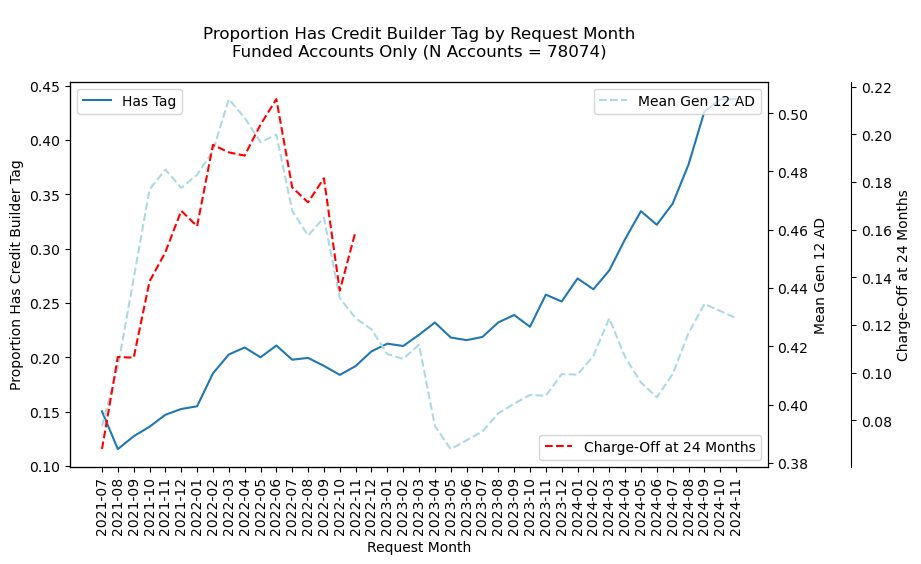

In [20]:
df_tmp = df.groupby(by='accountid', as_index=False).agg({
    'request_datetime': 'first',
    'has_inst_tag': 'max',
    'gen12_ad': 'mean',
    'co_at_720': 'first',
})
int_nrows = df_tmp.shape[0]
df_tmp['request_month'] = df_tmp['request_datetime'].apply(
    lambda x: str(x)[:7],
)
df_tmp['count'] = 1
df_tmp = df_tmp.groupby('request_month', as_index=False).agg({
    'count': 'sum',
    'has_inst_tag': 'mean',
    'gen12_ad': 'mean',
    'co_at_720': 'mean',
})

# graph
x = df_tmp['request_month']
y = df_tmp['has_inst_tag']
z = df_tmp['gen12_ad']
a = df_tmp['co_at_720']

# ax
fig, ax = plt.subplots(figsize=(9,5))
str_title = f"""
Proportion Has Credit Builder Tag by Request Month
Funded Accounts Only (N Accounts = {int_nrows})
"""
ax.set_title(str_title)
ax.set_xlabel('Request Month')
ax.set_ylabel('Proportion Has Credit Builder Tag')
ax.plot(x, y, label='Has Tag')
ax.tick_params(axis='x', rotation=90)
ax.legend(loc='upper left')

# second y
ax2 = ax.twinx()
ax2.set_ylabel('Mean Gen 12 AD')
ax2.plot(x, z, linestyle='--', color='lightblue', label='Mean Gen 12 AD')
# legend
ax2.legend(loc='upper right')

# third y
ax3 = ax.twinx()
ax3.spines['right'].set_position(('outward', 60))  # prevent overlap
ax3.set_ylabel('Charge-Off at 24 Months')
ax3.plot(x[:17], a[:17], linestyle='--', color='red', label='Charge-Off at 24 Months')
# legend
ax3.legend(loc='lower right')

# show
plt.show()

#### Overlay Gen 12 ECNL

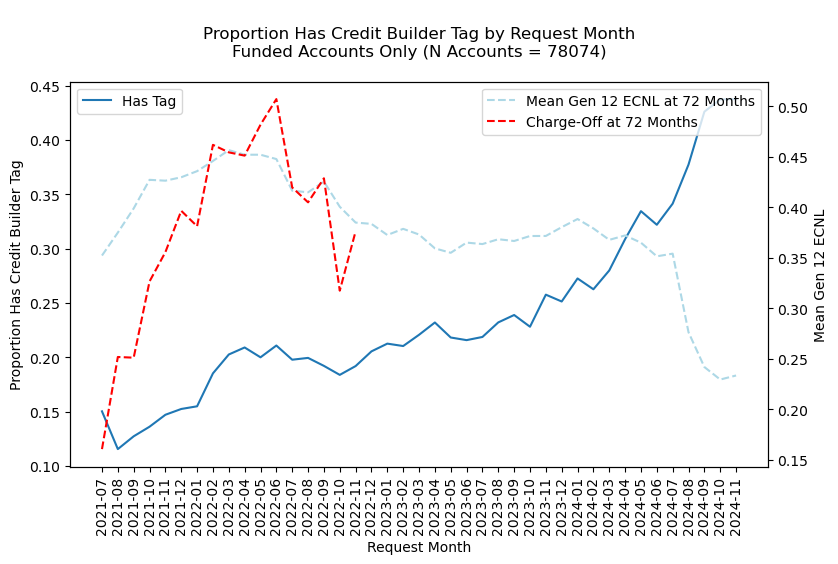

In [21]:
df_tmp = df.groupby(by='accountid', as_index=False).agg({
    'request_datetime': 'first',
    'has_inst_tag': 'max',
    'gen12_pd': 'mean',
    'gen12_lgd': 'mean',
    'co_at_720': 'first',
})
df_tmp['gen12_ecnl'] = df_tmp['gen12_pd'] * df_tmp['gen12_lgd'] * flt_factor_24_to_72
int_nrows = df_tmp.shape[0]
df_tmp['request_month'] = df_tmp['request_datetime'].apply(
    lambda x: str(x)[:7],
)
df_tmp['count'] = 1
df_tmp = df_tmp.groupby('request_month', as_index=False).agg({
    'count': 'sum',
    'has_inst_tag': 'mean',
    'gen12_ecnl': 'mean',
    'co_at_720': 'mean',
})

# graph
x = df_tmp['request_month']
y = df_tmp['has_inst_tag']
z = df_tmp['gen12_ecnl']
a = df_tmp['co_at_720'] * flt_factor_24_to_72

# ax
fig, ax = plt.subplots(figsize=(9,5))
str_title = f"""
Proportion Has Credit Builder Tag by Request Month
Funded Accounts Only (N Accounts = {int_nrows})
"""
ax.set_title(str_title)
ax.set_xlabel('Request Month')
ax.set_ylabel('Proportion Has Credit Builder Tag')
ax.plot(x, y, label='Has Tag')
ax.tick_params(axis='x', rotation=90)
ax.legend(loc='upper left')

# second y
ax2 = ax.twinx()
ax2.set_ylabel('Mean Gen 12 ECNL')
ax2.plot(x, z, linestyle='--', color='lightblue', label='Mean Gen 12 ECNL at 72 Months')
ax2.plot(x[:17], a[:17], linestyle='--', color='red', label='Charge-Off at 72 Months')
# legend
ax2.legend(loc='upper right')

# show
plt.show()

#### Overlay Gen 13 ECNL

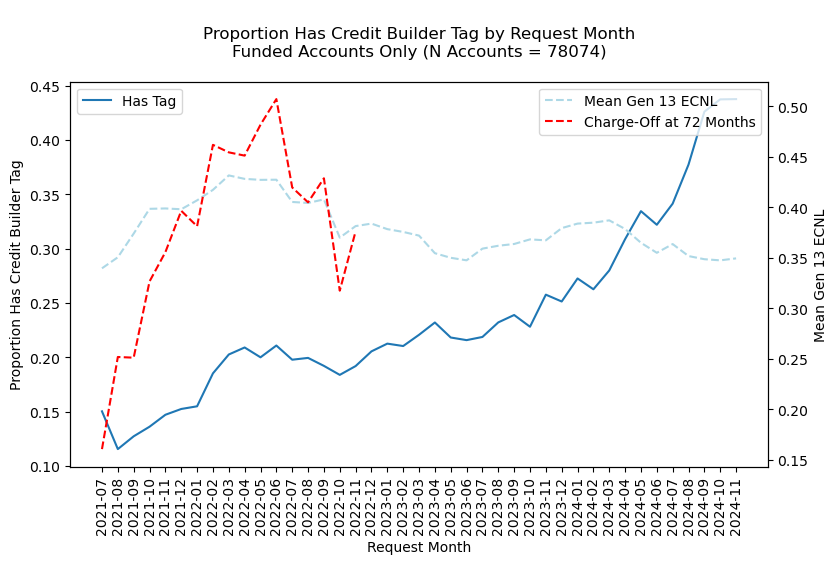

In [22]:
df_tmp = df.groupby(by='accountid', as_index=False).agg({
    'request_datetime': 'first',
    'has_inst_tag': 'max',
    'gen13_pd': 'mean',
    'gen13_lgd': 'mean',
    'co_at_720': 'first',
})
df_tmp['gen13_ecnl'] = df_tmp['gen13_pd'] * df_tmp['gen13_lgd'] * flt_factor_24_to_72
int_nrows = df_tmp.shape[0]
df_tmp['request_month'] = df_tmp['request_datetime'].apply(
    lambda x: str(x)[:7],
)
df_tmp['count'] = 1
df_tmp = df_tmp.groupby('request_month', as_index=False).agg({
    'count': 'sum',
    'has_inst_tag': 'mean',
    'gen13_ecnl': 'mean',
    'co_at_720': 'mean',
})

# graph
x = df_tmp['request_month']
y = df_tmp['has_inst_tag']
z = df_tmp['gen13_ecnl']
a = df_tmp['co_at_720'] * flt_factor_24_to_72

# ax
fig, ax = plt.subplots(figsize=(9,5))
str_title = f"""
Proportion Has Credit Builder Tag by Request Month
Funded Accounts Only (N Accounts = {int_nrows})
"""
ax.set_title(str_title)
ax.set_xlabel('Request Month')
ax.set_ylabel('Proportion Has Credit Builder Tag')
ax.plot(x, y, label='Has Tag')
ax.tick_params(axis='x', rotation=90)
ax.legend(loc='upper left')
# second y
ax2 = ax.twinx()
ax2.set_ylabel('Mean Gen 13 ECNL')
ax2.plot(x, z, linestyle='--', color='lightblue', label='Mean Gen 13 ECNL')
ax2.plot(x[:17], a[:17], linestyle='--', color='red', label='Charge-Off at 72 Months')
# legend
ax2.legend(loc='upper right')

# show
plt.show()

#### Overlay income

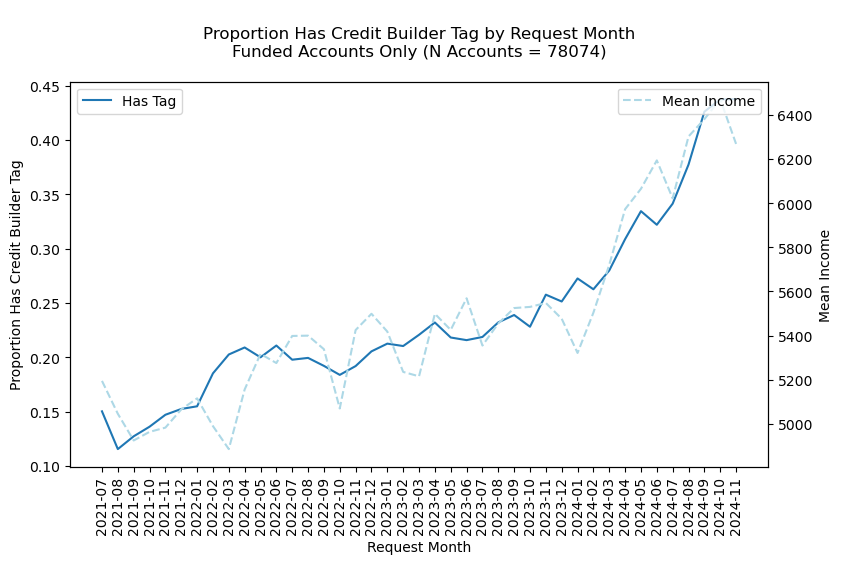

In [23]:
df_tmp = df.groupby(by='accountid', as_index=False).agg({
    'request_datetime': 'first',
    'has_inst_tag': 'max',
    'fltgrossmonthly__income_sum': 'sum',
})
int_nrows = df_tmp.shape[0]
df_tmp['request_month'] = df_tmp['request_datetime'].apply(
    lambda x: str(x)[:7],
)
df_tmp = df_tmp.groupby('request_month', as_index=False).agg({
    'has_inst_tag': 'mean',
    'fltgrossmonthly__income_sum': 'mean',
})

# graph
x = df_tmp['request_month']
y = df_tmp['has_inst_tag']
z = df_tmp['fltgrossmonthly__income_sum']
# ax
fig, ax = plt.subplots(figsize=(9,5))
str_title = f"""
Proportion Has Credit Builder Tag by Request Month
Funded Accounts Only (N Accounts = {int_nrows})
"""
ax.set_title(str_title)
ax.set_xlabel('Request Month')
ax.set_ylabel('Proportion Has Credit Builder Tag')
ax.plot(x, y, label='Has Tag')
ax.tick_params(axis='x', rotation=90)
ax.legend(loc='upper left')
# second y
ax2 = ax.twinx()
ax2.set_ylabel('Mean Income')
ax2.plot(x, z, linestyle='--', color='lightblue', label='Mean Income')
# legend
ax2.legend(loc='upper right')
# show
plt.show()

#### LTV

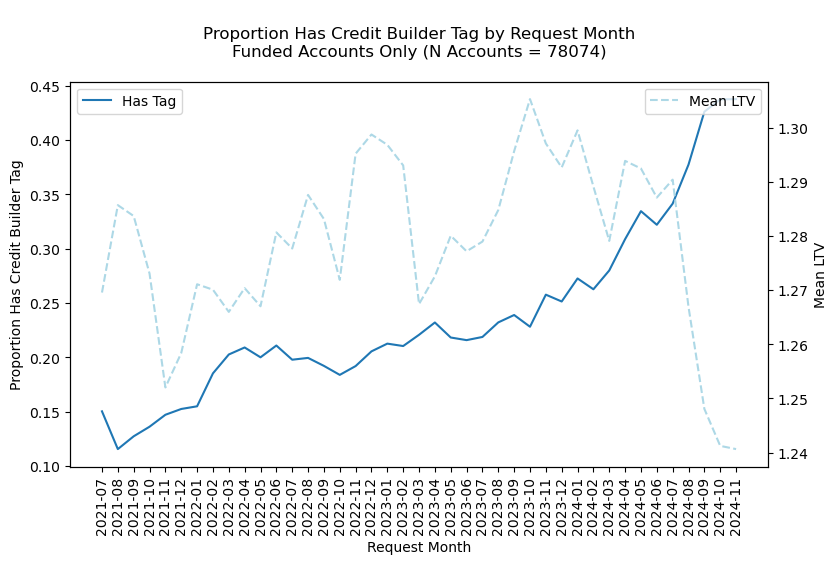

In [24]:
df_tmp = df.groupby(by='accountid', as_index=False).agg({
    'request_datetime': 'first',
    'has_inst_tag': 'max',
    'ENG-loan_to_value': 'first',
})
int_nrows = df_tmp.shape[0]
df_tmp['request_month'] = df_tmp['request_datetime'].apply(
    lambda x: str(x)[:7],
)
df_tmp = df_tmp.groupby('request_month', as_index=False).agg({
    'has_inst_tag': 'mean',
    'ENG-loan_to_value': 'mean',
})

# graph
x = df_tmp['request_month']
y = df_tmp['has_inst_tag']
z = df_tmp['ENG-loan_to_value']
# ax
fig, ax = plt.subplots(figsize=(9,5))
str_title = f"""
Proportion Has Credit Builder Tag by Request Month
Funded Accounts Only (N Accounts = {int_nrows})
"""
ax.set_title(str_title)
ax.set_xlabel('Request Month')
ax.set_ylabel('Proportion Has Credit Builder Tag')
ax.plot(x, y, label='Has Tag')
ax.tick_params(axis='x', rotation=90)
ax.legend(loc='upper left')
# second y
ax2 = ax.twinx()
ax2.set_ylabel('Mean LTV')
ax2.plot(x, z, linestyle='--', color='lightblue', label='Mean LTV')
# legend
ax2.legend(loc='upper right')
# show
plt.show()

#### Structure pivot

In [25]:
list_cols_dv = list_cols_structure + ['bad_pmt_hx']
df['count'] = 1
dict_tmp = {key: 'mean' for key in list_cols_dv}
dict_tmp['count'] = 'count'
df_tmp = df.groupby('has_inst_tag', as_index=False).agg(dict_tmp)

# map
dict_map = {
    1: 'Yes',
    0: 'No',
}
df_tmp['has_inst_tag'] = df_tmp['has_inst_tag'].map(dict_map)

# save locally
str_filename = 'df_pivot_all_ivs.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_tmp.to_csv(str_local_path, index=False)

# show
df_tmp

,has_inst_tag,ENG-wtd_avg,ENG-bk,bookvalue__app,amtfinanced__app,ENG-loan_to_value,fltgrossmonthly__income_sum,ENG-franchise,rp01s__tu,g232s__tu,g106s__tu,ENG-has_codebtor,ENG-has_auto,derogseverityindex__ln,balmag01__tu,cv15__tu,bad_pmt_hx,count
0,No,0.689301,0.240355,18559.897209,23326.784264,1.281648,4480.434727,0.612872,0.111360,11.830246,261.736321,0.362612,0.722732,1.146198,259.438761,2.197999,0.216546,75014
1,Yes,0.626674,0.265645,18110.072856,22842.362730,1.284697,4573.349871,0.603157,0.135686,15.165764,228.207501,0.280916,0.750967,1.354818,280.619963,2.581350,0.273539,19383


#### Rm too new so we can look at targets

In [26]:
df = df[df['request_datetime'] <= '2022-11-26'].copy()
df

,request_datetime,accountid,bitdebtor,ENG-wtd_avg,ENG-bk,bookvalue__app,amtfinanced__app,ENG-loan_to_value,fltgrossmonthly__income_sum,ENG-franchise,...,BRIGHT BLDR_tag,FIG TECH INC_tag,SELF/RENT_tag,SELFBILLSE_tag,PROGRESSRES_tag,FLEX_tag,FLEXFINANCE_tag,sum,has_inst_tag,count
0,2021-07-26 16:29:29.3903686,5702434,1,0.616667,1,10900.0,14292.30,1.311220,2426.67,1,...,0,0,0,0,0,0,0,0,0,1
1,2021-07-26 16:39:34.1121025,5714239,1,NaN,0,17294.0,24771.37,1.432368,5809.68,1,...,0,0,0,0,0,0,0,0,0,1
2,2021-07-26 16:48:39.3211104,5713063,1,NaN,1,10830.0,17188.00,1.587073,3758.84,1,...,0,0,0,0,0,0,0,0,0,1
3,2021-07-27 09:02:35.3300974,5713732,1,1.000000,0,24150.0,26127.42,1.081881,5416.67,0,...,0,0,0,0,0,0,0,1,1,1
4,2021-07-27 09:18:12.2190097,5715634,1,1.000000,0,13530.0,18554.36,1.371350,4786.97,1,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41387,2022-11-25 23:17:46+00:00,6449613,1,0.464643,0,14675.0,22164.00,1.510324,4333.33,1,...,0,0,0,0,0,0,0,0,0,1
41388,2022-11-25 23:21:35+00:00,6436672,1,0.771429,0,30200.0,32481.00,1.075530,4747.77,0,...,0,0,0,0,0,0,0,0,0,1
41389,2022-11-25 23:26:06+00:00,6448141,1,0.083004,0,22600.0,25278.37,1.118512,5200.00,1,...,0,0,0,0,0,0,0,0,0,1
41390,2022-11-25 23:49:40+00:00,6439773,1,NaN,0,17535.0,21160.14,1.206737,4088.31,0,...,0,0,0,0,0,0,0,0,0,1


#### ECNLs, Delinquency, and CO severity

In [27]:
# ecnl at account level
df_tmp = df.groupby(by='accountid', as_index=False).agg({
    'has_inst_tag': 'max',
    'gen12_ad': 'mean',
    'gen12_pd': 'mean',
    'gen12_lgd': 'mean',
    'gen13_pd': 'mean',
    'gen13_lgd': 'mean',
    'co_at_720': 'first',
    '60_plus_pos_co_at_720': 'first',
    'Early_Pay_Delinquency_60_720_Flag': 'first',
})
int_n_accounts = df_tmp.shape[0]
print(f'Accounts after subsetting: {int_n_accounts}')
# get ecnl
df_tmp['gen12_ecnl_24'] = df_tmp['gen12_pd'] * df_tmp['gen12_lgd']
df_tmp['gen13_ecnl_24'] = df_tmp['gen13_pd'] * df_tmp['gen13_lgd']
# group
df_tmp = df_tmp.groupby(by='has_inst_tag', as_index=False).agg({
    'gen12_ad': 'mean',
    'gen12_pd': 'mean',
    'gen12_lgd': 'mean',
    'gen13_pd': 'mean',
    'gen13_lgd': 'mean',
    'gen12_ecnl_24': 'mean',
    'gen13_ecnl_24': 'mean',
    'co_at_720': 'mean',
    '60_plus_pos_co_at_720': 'mean',
    'Early_Pay_Delinquency_60_720_Flag': 'mean',
})

# convert back to Yes No
dict_map = {
    1: 'Yes',
    0: 'No',
}
df_tmp['has_inst_tag'] = df_tmp['has_inst_tag'].map(dict_map)

# suggested factors
df_tmp['gen12_suggested_factor'] = df_tmp['co_at_720'] / df_tmp['gen12_ecnl_24']
df_tmp['gen13_suggested_factor'] = df_tmp['co_at_720'] / df_tmp['gen13_ecnl_24']

# save
str_filename = 'df_pivot_subset_targets_and_predictions.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_tmp.to_csv(str_local_path, index=False)

# show
df_tmp

Accounts after subsetting: 33443


,has_inst_tag,gen12_ad,gen12_pd,gen12_lgd,gen13_pd,gen13_lgd,gen12_ecnl_24,gen13_ecnl_24,co_at_720,60_plus_pos_co_at_720,Early_Pay_Delinquency_60_720_Flag,gen12_suggested_factor,gen13_suggested_factor
0,No,0.462054,0.265838,0.657658,0.463771,0.354302,0.175784,0.166421,0.155805,0.247560,0.442414,0.886345,0.936211
1,Yes,0.504895,0.303226,0.663043,0.531665,0.357624,0.202124,0.191413,0.230189,0.350592,0.595825,1.138848,1.202576


#### Analyze targets

In [28]:
df_tmp = df.groupby(by='accountid', as_index=False).agg({
    'has_inst_tag': 'max',
    'Early_Pay_Delinquency_15_60_Flag': 'first',
    'Early_Pay_Delinquency_30_90_Flag': 'first',
    'Early_Pay_Delinquency_30_180_Flag': 'first',
    'Early_Pay_Delinquency_30_360_Flag': 'first',
    'Early_Pay_Delinquency_60_720_Flag': 'first',
    'co_at_720': 'first',
    '60_plus_pos_co_at_720': 'first',
    'Early_Pay_Delinquency_60_720_Flag': 'first',
})
# group by
df_tmp = df_tmp.groupby(by='has_inst_tag', as_index=False).agg({
    'Early_Pay_Delinquency_15_60_Flag': 'mean',
    'Early_Pay_Delinquency_30_90_Flag': 'mean',
    'Early_Pay_Delinquency_30_180_Flag': 'mean',
    'Early_Pay_Delinquency_30_360_Flag': 'mean',
    'Early_Pay_Delinquency_60_720_Flag': 'mean',
    'co_at_720': 'mean',
    '60_plus_pos_co_at_720': 'mean',
    'Early_Pay_Delinquency_60_720_Flag': 'mean',
})

# map
dict_map = {
    1: 'Yes',
    0: 'No',
}
df_tmp['has_inst_tag'] = df_tmp['has_inst_tag'].map(dict_map)

# save
str_filename = 'df_pivot_subset_targets.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_tmp.to_csv(str_local_path, index=False)

# show
df_tmp

,has_inst_tag,Early_Pay_Delinquency_15_60_Flag,Early_Pay_Delinquency_30_90_Flag,Early_Pay_Delinquency_30_180_Flag,Early_Pay_Delinquency_30_360_Flag,Early_Pay_Delinquency_60_720_Flag,co_at_720,60_plus_pos_co_at_720
0,No,0.132242,0.109617,0.255492,0.438832,0.442414,0.155805,0.247560
1,Yes,0.195102,0.170776,0.376397,0.602071,0.595825,0.230189,0.350592
